# **TUGAS KELOMPOK DATA WRANGLING**
### **Pre-Processing dan Klasifikasi Data Pasien ICU untuk Prediksi Kelangsungan Hidup** 

### A. Deskripsi Dataset
Dataset yang digunakan adalah **ICU Survival Prediction** dari **Kaggle**. Dataset berisi data pasien ICU yang digunakan untuk memprediksi apakah pasien dapat bertahan hidup selama perawatan di ICU.

Dataset yang digunakan adalah file:

train (6).csv 

Memiliki: 
1. 4.580 baris
2. 16 kolom
3. Variabel target/label **survived_icu** dengan nilai **0=pasien tidak selamat** dan **1=pasiem selamat**
4. Variabel input=informasi demografis dan kondisi klinis pasien, seperti umur, gender, BMI, denyut jantung, tekanan darah, saturasi oksigen, kadar glukosa, kreatinin, jumlah sel darah putih, tingkat keparahan penyakit, kebutuhan ventilator, dan jumlah kondisi kronis

### B. Tujuan Pre-Processing
1. Mengidentifikasi data yang hilang
2. Menangani missing value
3. Mengidentifikasi dan menangani outlier
4. Memastikan tidak terdapat data duplikat
5. Memisahkan fitur dan target 
6. Melakukan standardisasi data
7. Mempersiapkan dataset untuk supervised learning
8. Mengevaluasi kemampuan model dalam melakukan klasifikasi
---
after revisiii
1. Data understanding
2. Penjelasan setiap kolom
3. Pemeriksaan missing value, duplicate, noise, outlier, dan consistency
4. Data cleaning
5. Histogram, boxplot, dan heatmap
6. Split data
7. Preprocessing untuk **supervised learning**
8. **Logistic Regression**
9. Evaluasi dan interpretasi hasil

Anggota Kelompok:
1. Ahdila Putri Tahta Rohma (269) 
2. Aulia Mayza Widianto (131)
3. Ibnu A. Zahran Latua (053) 

## 1. Import Library & Data Gathering

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

In [2]:
df = pd.read_csv("train (6).csv")

print("Dataset berhasil dimuat.")
print("Ukuran dataset:", df.shape)
display(df.head(15))

Dataset berhasil dimuat.
Ukuran dataset: (4580, 16)


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
0,ICU_00301,51,1,20.0,78.6,128.3,67.1,13.7,92.4,40.0,2.98,1.45,14,0,1,1
1,ICU_05027,54,0,25.5,124.2,146.4,91.9,19.4,83.9,129.6,0.31,4.67,14,1,1,0
2,ICU_00475,57,0,27.6,124.7,127.6,78.3,10.4,100.0,274.0,4.37,10.32,24,1,1,0
3,ICU_04732,43,1,24.8,89.9,123.3,67.3,17.8,92.5,218.4,1.94,24.55,15,1,4,0
4,ICU_01889,61,0,21.4,96.1,187.0,71.6,25.1,86.2,126.5,0.37,8.47,3,0,1,1
5,ICU_02045,82,0,23.5,89.4,122.8,64.7,34.2,100.0,220.5,1.83,1.00,6,0,3,0
6,ICU_04097,51,1,NaN,57.1,143.2,53.8,NaN,NaN,90.2,NaN,NaN,3,0,0,0
7,ICU_05817,65,1,28.6,54.1,114.3,61.0,20.8,97.9,221.8,0.49,7.63,19,0,5,1
8,ICU_00734,80,0,24.1,62.6,123.0,76.4,15.6,100.0,135.4,0.42,6.69,3,1,1,0
9,ICU_03391,47,1,12.1,77.5,158.0,69.0,27.8,100.0,185.9,0.30,13.70,20,0,1,1


## 2. Data Understanding

Dataset berisi data pasien ICU. Target yang ingin diprediksi adalah **survived_icu**.

- **survived_icu = 1** → pasien selamat
- **survived_icu = 0** → pasien tidak selamat

Karena target memiliki dua kelas, masalah ini termasuk **klasifikasi (diskrit) biner** dan pengecekan nilai unik pada fitur dalam data


In [3]:
print("Informasi dataset:")
df.info()

print("\nStatistik deskriptif:")
display(df.describe().T)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4580 entries, 0 to 4579
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            4580 non-null   object 
 1   age                   4580 non-null   int64  
 2   gender                4580 non-null   int64  
 3   bmi                   3959 non-null   float64
 4   heart_rate            4580 non-null   float64
 5   systolic_bp           4580 non-null   float64
 6   diastolic_bp          4580 non-null   float64
 7   respiratory_rate      4005 non-null   float64
 8   oxygen_saturation     3977 non-null   float64
 9   glucose               4580 non-null   float64
 10  creatinine            3939 non-null   float64
 11  wbc_count             3772 non-null   float64
 12  severity_score        4580 non-null   int64  
 13  ventilation_required  4580 non-null   int64  
 14  chronic_conditions    4580 non-null   int64  
 15  su

,count,mean,std,min,25%,50%,75%,max
age,4580.0,61.436245,17.154096,18.0,50.000,62.00,73.0000,95.000000
gender,4580.0,0.532096,0.499023,0.0,0.000,1.00,1.0000,1.000000
bmi,3959.0,27.009093,7.507568,9.0,21.600,26.40,31.7000,57.000000
heart_rate,4580.0,99.210786,84.479186,30.0,73.900,89.00,103.7000,1207.839980
systolic_bp,4580.0,133.573375,117.907364,60.0,98.600,118.30,138.8000,1645.595945
diastolic_bp,4580.0,71.957969,17.337162,30.0,59.800,72.20,83.8000,130.000000
respiratory_rate,4005.0,18.061673,5.886609,6.0,13.900,18.00,22.1000,37.300000
oxygen_saturation,3977.0,94.565954,4.385576,78.4,91.700,95.00,98.4000,100.000000
glucose,4580.0,159.452983,156.701082,40.0,99.775,141.10,183.8250,2256.210085
creatinine,3939.0,1.373065,1.828402,0.3,0.360,0.89,1.7500,48.737770


In [4]:
attr_types = pd.DataFrame([
    ("patient_id", "Nominal", "ID pasien; hanya identitas, tidak dipakai sebagai fitur model."),
    ("age", "Rasio", "Usia pasien dalam tahun."),
    ("gender", "Nominal", "Jenis kelamin, sudah dikodekan 0/1."),
    ("bmi", "Rasio", "Body Mass Index."),
    ("heart_rate", "Rasio", "Denyut jantung per menit."),
    ("systolic_bp", "Rasio", "Tekanan darah sistolik."),
    ("diastolic_bp", "Rasio", "Tekanan darah diastolik."),
    ("respiratory_rate", "Rasio", "Frekuensi napas per menit."),
    ("oxygen_saturation", "Rasio", "Saturasi oksigen (%)."),
    ("glucose", "Rasio", "Kadar glukosa darah."),
    ("creatinine", "Rasio", "Kadar kreatinin."),
    ("wbc_count", "Rasio", "Jumlah sel darah putih."),
    ("severity_score", "Ordinal", "Skor tingkat keparahan pasien."),
    ("ventilation_required", "Nominal", "Apakah pasien membutuhkan ventilator, 0/1."),
    ("chronic_conditions", "Rasio", "Jumlah penyakit kronis."),
    ("survived_icu", "Nominal", "TARGET: 1 = selamat, 0 = tidak selamat.")
], columns=["Kolom", "Tipe", "Penjelasan"])

display(attr_types)

,Kolom,Tipe,Penjelasan
0,patient_id,Nominal,"ID pasien; hanya identitas, tidak dipakai seba..."
1,age,Rasio,Usia pasien dalam tahun.
2,gender,Nominal,"Jenis kelamin, sudah dikodekan 0/1."
3,bmi,Rasio,Body Mass Index.
4,heart_rate,Rasio,Denyut jantung per menit.
5,systolic_bp,Rasio,Tekanan darah sistolik.
6,diastolic_bp,Rasio,Tekanan darah diastolik.
7,respiratory_rate,Rasio,Frekuensi napas per menit.
8,oxygen_saturation,Rasio,Saturasi oksigen (%).
9,glucose,Rasio,Kadar glukosa darah.


In [5]:
kolom_kategori = [
    "gender",
    "ventilation_required",
    "survived_icu",
    "severity_score",
    "chronic_conditions"
]

for kolom in kolom_kategori:
    print(f"\n{kolom}")
    print("Nilai unik :", sorted(df[kolom].dropna().unique()))
    print("Jumlah unik:", df[kolom].nunique())


gender
Nilai unik : [np.int64(0), np.int64(1)]
Jumlah unik: 2

ventilation_required
Nilai unik : [np.int64(0), np.int64(1)]
Jumlah unik: 2

survived_icu
Nilai unik : [np.int64(0), np.int64(1)]
Jumlah unik: 2

severity_score
Nilai unik : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
Jumlah unik: 25

chronic_conditions
Nilai unik : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Jumlah unik: 6


## 3. Data Quality

Tiga aspek utama kualitas data yang diperiksa:

- **Accuracy:** apakah nilai masuk akal?
- **Completeness:** apakah ada nilai yang hilang?
- **Consistency:** apakah antar-data konsisten?

Dan juga memeriksa duplicate dan outlier.

### 3.1 Missing Value

In [6]:
missing = pd.DataFrame({
    "jumlah_missing": df.isna().sum(),
    "persentase_missing": (df.isna().mean() * 100).round(2)
}).sort_values("jumlah_missing", ascending=False)

display(missing)

,jumlah_missing,persentase_missing
wbc_count,808,17.64
creatinine,641,14.00
bmi,621,13.56
oxygen_saturation,603,13.17
respiratory_rate,575,12.55
gender,0,0.00
age,0,0.00
patient_id,0,0.00
diastolic_bp,0,0.00
systolic_bp,0,0.00


In [7]:
df_missing = df[df.isna().any(axis=1)]

print("Jumlah pasien yang memiliki minimal satu missing value:")
print(len(df_missing))

display(df_missing.head(15))

Jumlah pasien yang memiliki minimal satu missing value:
808


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
6,ICU_04097,51,1,NaN,57.1,143.2,53.8,NaN,NaN,90.2,NaN,NaN,3,0,0,0
17,ICU_03155,32,0,NaN,91.1,123.6,83.9,NaN,NaN,163.4,NaN,NaN,15,1,0,0
20,ICU_04227,69,0,NaN,77.4,149.2,91.3,NaN,NaN,133.6,NaN,NaN,4,1,5,1
21,ICU_02534,54,1,NaN,126.6,172.4,56.1,NaN,NaN,75.4,NaN,NaN,11,1,2,1
22,ICU_00433,74,0,NaN,105.8,130.5,61.5,NaN,NaN,157.5,NaN,NaN,17,1,4,1
23,ICU_02454,74,1,24.9,86.7,181.7,111.9,19.9,86.9,199.6,0.97,NaN,7,1,2,0
28,ICU_04704,72,0,NaN,103.7,100.4,75.3,19.4,92.9,266.6,NaN,NaN,22,0,1,1
31,ICU_01850,50,1,NaN,70.7,101.9,48.4,NaN,NaN,145.8,NaN,NaN,0,1,4,0
38,ICU_01500,76,0,34.8,45.1,132.5,79.9,27.0,92.2,144.3,0.30,NaN,23,1,3,0
41,ICU_02726,80,0,NaN,98.8,134.3,76.6,NaN,NaN,102.8,NaN,NaN,2,0,1,1


In [8]:
missing_cols = ["bmi","respiratory_rate","oxygen_saturation","creatinine","wbc_count"]
missing_pattern = (df[missing_cols].isna().astype(int))

def nama_pola(row):
    kolom_missing = [
        col
        for col in missing_cols
        if row[col] == 1
    ]

    if len(kolom_missing) == 0:
        return "Tidak ada missing"

    return ", ".join(kolom_missing)
missing_pattern["pola"] = (missing_pattern.apply(nama_pola,axis=1))
display(missing_pattern["pola"].value_counts().rename("jumlah").to_frame())

,jumlah
pola,
Tidak ada missing,3772
"bmi, respiratory_rate, oxygen_saturation, creatinine, wbc_count",575
wbc_count,167
"bmi, oxygen_saturation, creatinine, wbc_count",28
"creatinine, wbc_count",20
"bmi, creatinine, wbc_count",18


In [9]:
mask_5_missing = (
    df["bmi"].isna()
    & df["respiratory_rate"].isna()
    & df["oxygen_saturation"].isna()
    & df["creatinine"].isna()
    & df["wbc_count"].isna()
)
print("Jumlah pasien:",mask_5_missing.sum())
display(df.loc[mask_5_missing,].head(20))

Jumlah pasien: 575


,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
6,ICU_04097,51,1,NaN,57.1,143.2,53.8,NaN,NaN,90.2,NaN,NaN,3,0,0,0
17,ICU_03155,32,0,NaN,91.1,123.6,83.9,NaN,NaN,163.4,NaN,NaN,15,1,0,0
20,ICU_04227,69,0,NaN,77.4,149.2,91.3,NaN,NaN,133.6,NaN,NaN,4,1,5,1
21,ICU_02534,54,1,NaN,126.6,172.4,56.1,NaN,NaN,75.4,NaN,NaN,11,1,2,1
22,ICU_00433,74,0,NaN,105.8,130.5,61.5,NaN,NaN,157.5,NaN,NaN,17,1,4,1
31,ICU_01850,50,1,NaN,70.7,101.9,48.4,NaN,NaN,145.8,NaN,NaN,0,1,4,0
41,ICU_02726,80,0,NaN,98.8,134.3,76.6,NaN,NaN,102.8,NaN,NaN,2,0,1,1
57,ICU_03759,61,1,NaN,71.0,128.4,80.9,NaN,NaN,87.1,NaN,NaN,8,0,1,0
71,ICU_04038,61,0,NaN,91.8,83.3,99.0,NaN,NaN,192.5,NaN,NaN,7,0,2,0
86,ICU_01155,80,1,NaN,78.0,173.3,90.9,NaN,NaN,95.3,NaN,NaN,10,1,0,0


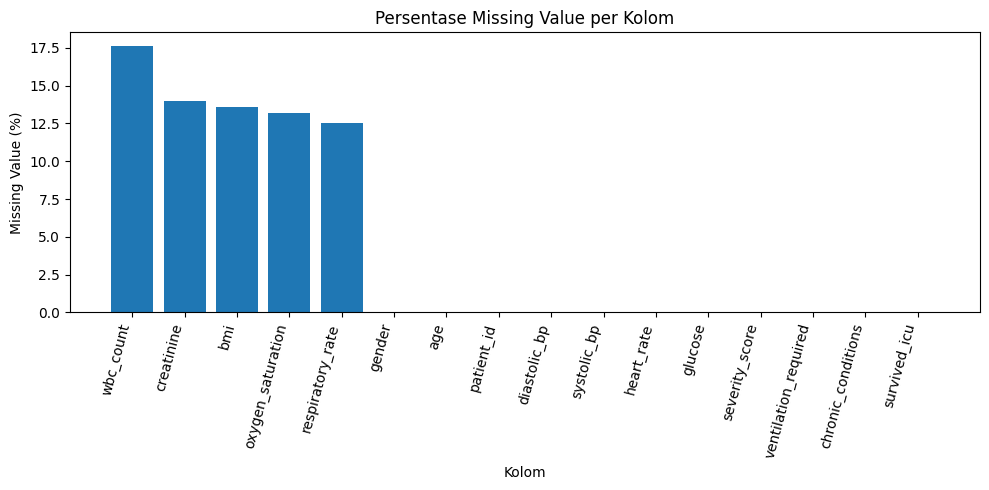

Jumlah baris yang memiliki minimal satu missing value: 808


In [10]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(missing_pct.index, missing_pct.values)
plt.title("Persentase Missing Value per Kolom")
plt.xlabel("Kolom")
plt.ylabel("Missing Value (%)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

print("Jumlah baris yang memiliki minimal satu missing value:",
      df.isna().any(axis=1).sum())

### 3.2 Duplicate

In [11]:
print("Duplicate seluruh kolom:", df.duplicated().sum())
print("Duplicate patient_id:", df["patient_id"].duplicated().sum())

tanpa_id = df.drop(columns=["patient_id"])
print("Baris yang terlibat duplicate berdasarkan fitur + target:",
      tanpa_id.duplicated(keep=False).sum())

Duplicate seluruh kolom: 0
Duplicate patient_id: 0
Baris yang terlibat duplicate berdasarkan fitur + target: 116


In [12]:
tanpa_id = df.drop(columns=["patient_id"])
duplicate_mask = tanpa_id.duplicated(keep=False)
data_duplicate = (df.loc[duplicate_mask].sort_values(by=list(tanpa_id.columns)))

display(data_duplicate)

,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
369,ICU_DUP_0042,18,1,35.3,97.5,149.0,34.1,24.4,92.9,155.6,0.30,3.49,21,0,5,1
2820,ICU_05907,18,1,35.3,97.5,149.0,34.1,24.4,92.9,155.6,0.30,3.49,21,0,5,1
3378,ICU_00013,27,1,28.7,132.0,115.8,70.2,14.5,97.0,202.1,2.27,16.12,22,0,0,1
4547,ICU_DUP_0030,27,1,28.7,132.0,115.8,70.2,14.5,97.0,202.1,2.27,16.12,22,0,0,1
1965,ICU_02280,30,0,27.2,109.4,106.5,96.2,10.3,92.4,148.5,1.10,17.42,18,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,ICU_DUP_0029,95,1,20.7,71.0,66.4,63.8,13.4,91.8,204.5,3.33,22.91,22,0,5,0
3349,ICU_DUP_0008,95,1,28.6,49.6,122.6,95.1,18.0,90.4,144.1,1.77,22.77,9,1,2,1
4168,ICU_03982,95,1,28.6,49.6,122.6,95.1,18.0,90.4,144.1,1.77,22.77,9,1,2,1
766,ICU_DUP_0015,95,1,32.9,64.5,195.2,69.6,19.6,85.7,250.1,0.96,43.03,15,1,1,0


In [13]:
id_normal = df["patient_id"].str.match(r"^ICU_\d{5}$")
id_duplicate_style = df["patient_id"].str.match(r"^ICU_DUP_\d{4}$")
id_invalid = ~(id_normal | id_duplicate_style)
print("ID normal        :", id_normal.sum())
print("ID pola DUP      :", id_duplicate_style.sum())
print("ID tidak dikenal :", id_invalid.sum())

ID normal        : 4500
ID pola DUP      : 80
ID tidak dikenal : 0


In [14]:
display(df[df["patient_id"].str.startswith("ICU_DUP_")].head(15))

,patient_id,age,gender,bmi,heart_rate,systolic_bp,diastolic_bp,respiratory_rate,oxygen_saturation,glucose,creatinine,wbc_count,severity_score,ventilation_required,chronic_conditions,survived_icu
34,ICU_DUP_0018,43,1,21.4,87.3,139.4,98.1,11.2,85.5,262.5,0.36,1.08,10,0,1,1
54,ICU_DUP_0061,53,1,32.0,94.1,97.7,50.0,27.1,96.2,69.2,3.04,1.00,23,0,0,1
82,ICU_DUP_0043,58,1,23.2,116.6,129.2,82.1,8.3,90.9,92.5,0.31,11.28,23,1,1,0
369,ICU_DUP_0042,18,1,35.3,97.5,149.0,34.1,24.4,92.9,155.6,0.30,3.49,21,0,5,1
396,ICU_DUP_0028,71,0,26.4,95.8,155.4,89.7,18.4,89.8,122.7,0.32,4.09,8,0,3,0
410,ICU_DUP_0047,79,0,22.7,105.1,112.2,87.7,12.7,100.0,222.2,0.33,10.89,7,0,0,0
416,ICU_DUP_0074,80,1,28.4,102.1,189.0,130.0,21.7,95.0,96.2,0.30,6.14,14,0,1,1
418,ICU_DUP_0020,51,0,NaN,53.2,106.6,63.6,NaN,NaN,236.5,NaN,NaN,0,0,3,0
463,ICU_DUP_0079,57,0,NaN,78.8,91.4,48.0,24.7,95.5,75.9,NaN,NaN,16,0,3,1
474,ICU_DUP_0013,39,0,21.0,104.0,105.8,67.2,23.0,99.3,119.6,0.30,1.00,23,0,0,1


In [15]:
df_cek = df.copy()

# Tandai ID DUP
mask_dup = df_cek["patient_id"].str.startswith("ICU_DUP_")

# angka di belakang ID
df_cek["nomor_id"] = (
    df_cek["patient_id"]
    .str.extract(r"(\d+)$")[0]
    .astype(int)
)

id_dup = df_cek.loc[mask_dup].copy()
id_normal = df_cek.loc[~mask_dup].copy()

# Cari nomor ICU_DUP_ yang juga ada pada ID normal
pasangan_id = (
    id_dup[["patient_id", "nomor_id"]]
    .merge(
        id_normal[["patient_id", "nomor_id"]],
        on="nomor_id",
        how="inner",
        suffixes=("_dup", "_normal")
    )
)

print("Jumlah ICU_DUP_ pada data mentah:", len(id_dup))
print("Jumlah yang nomor belakangnya sama dengan ID normal:", len(pasangan_id))

display(pasangan_id)

Jumlah ICU_DUP_ pada data mentah: 80
Jumlah yang nomor belakangnya sama dengan ID normal: 60


,patient_id_dup,nomor_id,patient_id_normal
0,ICU_DUP_0043,43,ICU_00043
1,ICU_DUP_0042,42,ICU_00042
2,ICU_DUP_0028,28,ICU_00028
3,ICU_DUP_0020,20,ICU_00020
4,ICU_DUP_0079,79,ICU_00079
5,ICU_DUP_0013,13,ICU_00013
6,ICU_DUP_0059,59,ICU_00059
7,ICU_DUP_0036,36,ICU_00036
8,ICU_DUP_0001,1,ICU_00001
9,ICU_DUP_0071,71,ICU_00071


In [16]:
df_id = df[["patient_id"]].copy()

df_id["nomor"] = (
    df_id["patient_id"]
    .str.extract(r"(\d+)$")[0]
    .astype(int)
)

df_id["jenis_id"] = (
    df_id["patient_id"]
    .str.startswith("ICU_DUP_")
    .map({
        True: "DUP",
        False: "NORMAL"
    })
)

df_id = (
    df_id
    .sort_values(
        by=["nomor", "jenis_id"]
    )
    .reset_index(drop=True)
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

display(df_id.head(40))

,patient_id,nomor,jenis_id
0,ICU_DUP_0000,0,DUP
1,ICU_00000,0,NORMAL
2,ICU_DUP_0001,1,DUP
3,ICU_00001,1,NORMAL
4,ICU_DUP_0002,2,DUP
5,ICU_DUP_0003,3,DUP
6,ICU_DUP_0004,4,DUP
7,ICU_00004,4,NORMAL
8,ICU_DUP_0005,5,DUP
9,ICU_00005,5,NORMAL


In [17]:
dup_id = df[
    df["patient_id"].str.startswith("ICU_DUP_")
].copy()

dup_id["nomor"] = (
    dup_id["patient_id"]
    .str.extract(r"(\d+)$")[0]
    .astype(int)
)

dup_id = dup_id.sort_values("nomor")

print("Jumlah ICU_DUP_:", len(dup_id))
print("Nomor minimum:", dup_id["nomor"].min())
print("Nomor maksimum:", dup_id["nomor"].max())
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
display(dup_id[["patient_id", "nomor"]])

Jumlah ICU_DUP_: 80
Nomor minimum: 0
Nomor maksimum: 79


,patient_id,nomor
860,ICU_DUP_0000,0
619,ICU_DUP_0001,1
4509,ICU_DUP_0002,2
911,ICU_DUP_0003,3
3404,ICU_DUP_0004,4
4246,ICU_DUP_0005,5
2928,ICU_DUP_0006,6
1717,ICU_DUP_0007,7
3349,ICU_DUP_0008,8
3682,ICU_DUP_0009,9


### 3.3 Outlier dan Boxplot

Pemriksaan Outlier dan **Boxplot** digunakan untuk melihat sebaran data dan nilai yang jauh dari kelompok utama. Titik di luar whisker biasanya dianggap kandidat outlier secara statistik. Namun, outlier tidak otomatis salah; karena itu kita juga memakai pemeriksaan logis/domain.

In [18]:
continuous_features = [
    "age",
    "bmi",
    "heart_rate",
    "systolic_bp",
    "diastolic_bp",
    "respiratory_rate",
    "oxygen_saturation",
    "glucose",
    "creatinine",
    "wbc_count"
]

In [19]:
hasil_outlier = []

for kolom in continuous_features:

    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier = (
        (df[kolom] < lower_bound) |
        (df[kolom] > upper_bound)
    )

    hasil_outlier.append({
        "fitur": kolom,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "jumlah_outlier": outlier.sum(),
        "persentase": round(outlier.mean() * 100, 2)
    })

outlier_table = pd.DataFrame(hasil_outlier)

display(outlier_table)

,fitur,lower_bound,upper_bound,jumlah_outlier,persentase
0,age,15.50000,107.50000,0,0.00
1,bmi,6.45000,46.85000,47,1.03
2,heart_rate,29.20000,148.40000,106,2.31
3,systolic_bp,38.30000,199.10000,101,2.21
4,diastolic_bp,23.80000,119.80000,16,0.35
5,respiratory_rate,1.60000,34.40000,8,0.17
6,oxygen_saturation,81.65000,108.45000,15,0.33
7,glucose,-26.30000,309.90000,95,2.07
8,creatinine,-1.72500,3.83500,198,4.32
9,wbc_count,-14.32375,31.44625,163,3.56


### 3.4 Pemeriksaan Nilai Tidak Logis

Beberapa aturan sederhana digunakan untuk mencari noise, misalnya nilai fisiologis negatif, saturasi di atas 100%, atau tekanan sistolik lebih kecil daripada diastolik.

In [20]:
logical_check = {
    "age < 0": (df["age"] < 0).sum(),
    "bmi <= 0": (df["bmi"] <= 0).sum(),
    "heart_rate <= 0": (df["heart_rate"] <= 0).sum(),
    "systolic_bp <= 0": (df["systolic_bp"] <= 0).sum(),
    "diastolic_bp <= 0": (df["diastolic_bp"] <= 0).sum(),
    "systolic < diastolic": (df["systolic_bp"] < df["diastolic_bp"]).sum(),
    "respiratory_rate <= 0": (df["respiratory_rate"] <= 0).sum(),
    "oxygen_saturation di luar 0-100":
        ((df["oxygen_saturation"] < 0) | (df["oxygen_saturation"] > 100)).sum(),
    "glucose <= 0": (df["glucose"] <= 0).sum(),
    "creatinine < 0": (df["creatinine"] < 0).sum(),
    "wbc_count < 0": (df["wbc_count"] < 0).sum()
}

display(pd.Series(logical_check, name="jumlah"))

age < 0                              0
bmi <= 0                             0
heart_rate <= 0                      0
systolic_bp <= 0                     0
diastolic_bp <= 0                    0
systolic < diastolic               344
respiratory_rate <= 0                0
oxygen_saturation di luar 0-100      0
glucose <= 0                         0
creatinine < 0                       0
wbc_count < 0                        0
Name: jumlah, dtype: int64

In [21]:
bp_anomali = df[df["systolic_bp"] < df["diastolic_bp"]]
display( bp_anomali[["patient_id","systolic_bp","diastolic_bp"]].head(20))

,patient_id,systolic_bp,diastolic_bp
12,ICU_03249,95.9,115.5
13,ICU_03997,68.7,80.4
65,ICU_04279,60.1,72.7
71,ICU_04038,83.3,99.0
97,ICU_02256,93.1,99.7
104,ICU_00764,81.0,89.3
118,ICU_05584,69.6,73.8
119,ICU_02566,60.0,88.8
133,ICU_00587,76.6,103.4
142,ICU_00290,76.7,94.3


### 3.5 Distribusi Data — Histogram

Histogram membantu melihat bentuk distribusi setiap fitur, misalnya apakah data terkonsentrasi pada rentang tertentu atau memiliki ekor panjang.

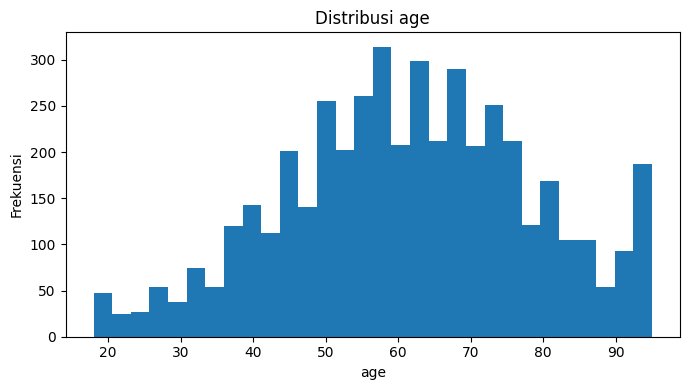

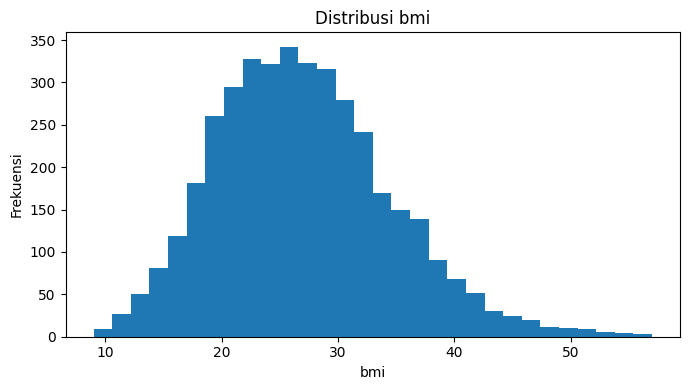

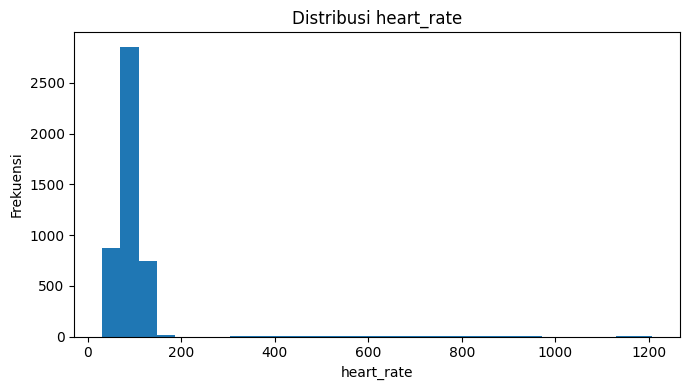

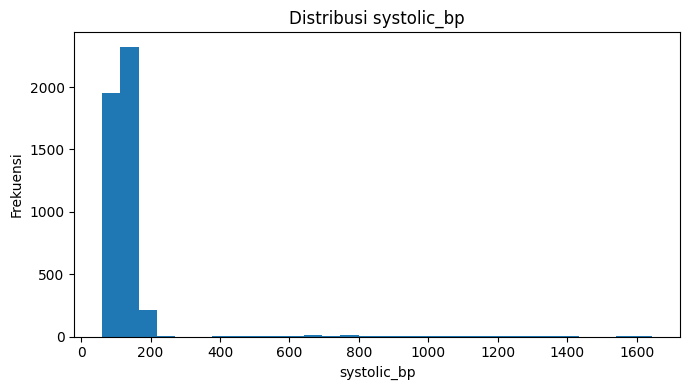

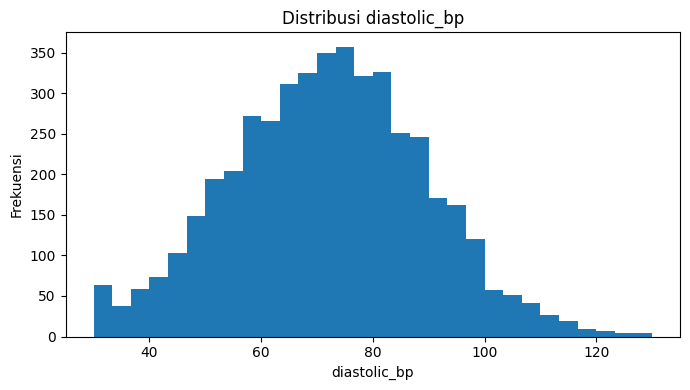

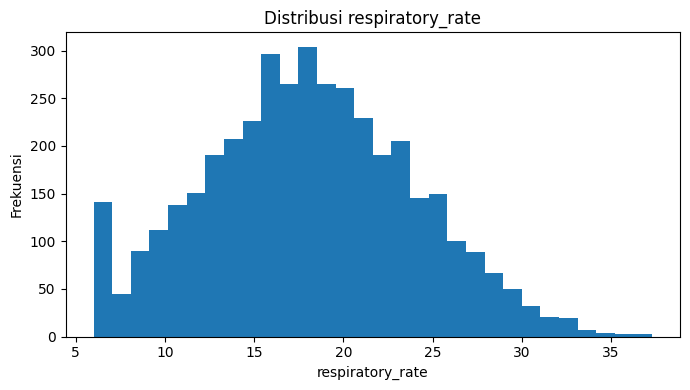

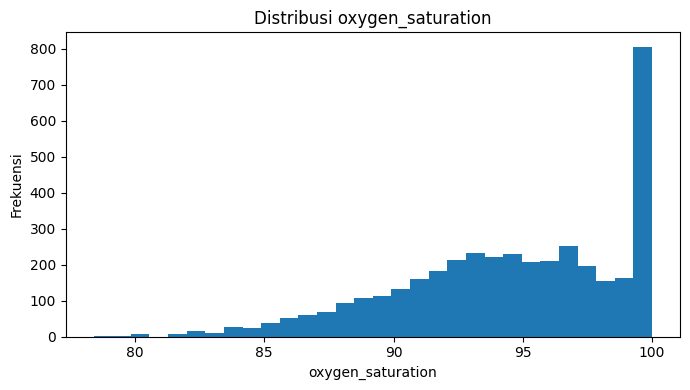

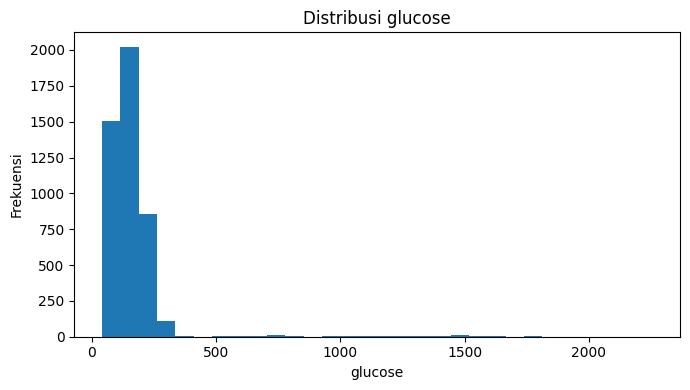

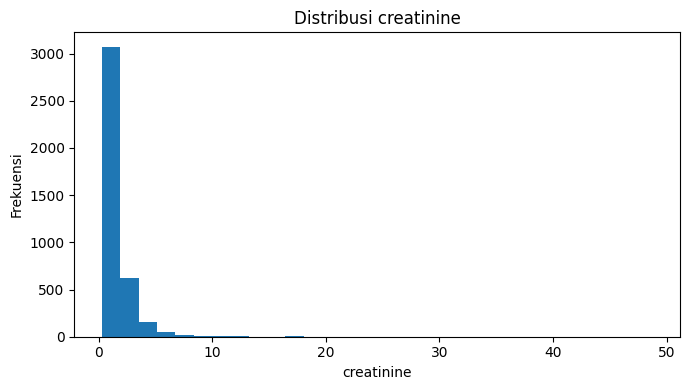

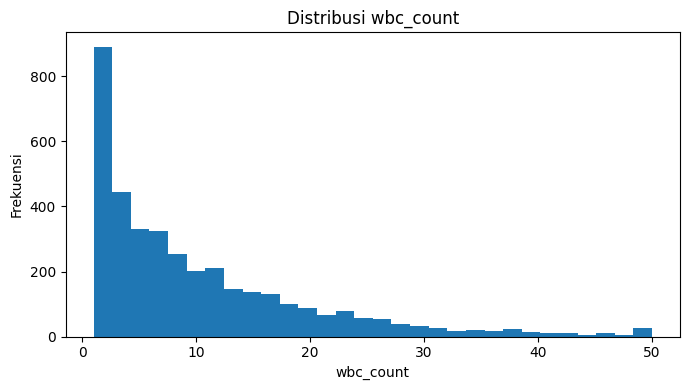

In [22]:
for col in continuous_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

## 4. Data Cleaning

Berdasarkan pemeriksaan sebelumnya, cleaning dilakukan dengan langkah sederhana:

1. Menghapus duplicate tambahan.
2. Menghapus baris yang jelas mengalami corrupted extreme values.
3. Memperbaiki kasus *systolic_bp < diastolic_bp* dengan menukar kedua nilai.
4. Missing value **tidak langsung dibuang**, tetapi akan ditangani dengan **median imputation** saat preprocessing model.

In [23]:
df_raw = df.copy()
df_clean = df.copy()

# 1. Hapus duplicate berdasarkan seluruh kolom selain patient_id.
non_id_cols = [c for c in df_clean.columns if c != "patient_id"]
df_clean["_is_dup_id"] = (df_clean["patient_id"].str.startswith("ICU_DUP_").astype(int))
df_clean = (df_clean.sort_values("_is_dup_id").reset_index(drop=True))

duplicate_mask = df_clean.duplicated(
    subset=non_id_cols,
    keep="first"
)
n_removed_duplicate = duplicate_mask.sum()
df_clean = df_clean.loc[~duplicate_mask].copy()
df_clean = (df_clean.drop(columns="_is_dup_id").reset_index(drop=True))

print("Duplicate ID_DUP yang dibuang:", n_removed_duplicate)
print("Ukuran setelah duplicate dibuang:",df_clean.shape)

Duplicate ID_DUP yang dibuang: 58
Ukuran setelah duplicate dibuang: (4522, 16)


In [24]:
dup_id_mask = (df_clean["patient_id"].str.startswith("ICU_DUP_"))
print("Jumlah ID ICU_DUP sisah:", dup_id_mask.sum()) 
display(df_clean.loc[dup_id_mask,["patient_id"]])

Jumlah ID ICU_DUP sisah: 22


,patient_id
4500,ICU_DUP_0023
4501,ICU_DUP_0063
4502,ICU_DUP_0078
4503,ICU_DUP_0057
4504,ICU_DUP_0045
4505,ICU_DUP_0024
4506,ICU_DUP_0006
4507,ICU_DUP_0077
4508,ICU_DUP_0041
4509,ICU_DUP_0011


In [51]:
# cek digit selain 0 di belakang ID DUP yang sama dengan ID normal
# Pisahkan ID DUP dan ID normal
id_dup = df_clean[df_clean["patient_id"].str.startswith("ICU_DUP_")].copy()

id_normal = df_clean[~df_clean["patient_id"].str.startswith("ICU_DUP_")].copy()

# Ambil angka di belakang ID
id_dup["nomor"] = (id_dup["patient_id"].str.extract(r"(\d+)$")[0].astype(int))

id_normal["nomor"] = (id_normal["patient_id"].str.extract(r"(\d+)$")[0].astype(int))

# Cek apakah nomor ICU_DUP_ sudah ada di ID normal
cek_sama = id_dup["nomor"].isin(id_normal["nomor"])

print("Jumlah nomor DUP yang sudah ada di ID normal:",cek_sama.sum())

Jumlah nomor DUP yang sudah ada di ID normal: 17


In [ ]:
# cek pola pola digit di belakang ID DUP
pasangan_id = (
    id_dup[["patient_id", "nomor"]]
    .merge(
        id_normal[["patient_id", "nomor"]],
        on="nomor",
        how="inner",
        suffixes=("_dup", "_normal")
    )
)

display(pasangan_id)

,patient_id_dup,nomor,patient_id_normal
0,ICU_DUP_0023,23,ICU_00023
1,ICU_DUP_0063,63,ICU_00063
2,ICU_DUP_0078,78,ICU_00078
3,ICU_DUP_0045,45,ICU_00045
4,ICU_DUP_0024,24,ICU_00024
5,ICU_DUP_0006,6,ICU_00006
6,ICU_DUP_0041,41,ICU_00041
7,ICU_DUP_0011,11,ICU_00011
8,ICU_DUP_0073,73,ICU_00073
9,ICU_DUP_0000,0,ICU_00000


In [27]:
# pemeriksaan nilai extreme corrupt pada heart_rate dan systolic_bp
cek_extreme_corrupt = { "heart_rate": 250,"systolic_bp": 300}
for col, batas in cek_extreme_corrupt.items():
    print(f"{col} tertinggi <= {batas}:",df_clean.loc[df_clean[col] <= batas,col].max())
    print(f"{col} terendah > {batas}:",df_clean.loc[df_clean[col] > batas,col].min())
    print()

heart_rate tertinggi <= 250: 169.2
heart_rate terendah > 250: 314.5521893515285

systolic_bp tertinggi <= 300: 220.0
systolic_bp terendah > 300: 381.7834844177826



In [28]:
extreme_both = (
    (df_clean["heart_rate"] > 250)
    &
    (df_clean["systolic_bp"] > 300)
)
df_92_extreme =(  df_clean.loc[extreme_both].copy())
print("Jumlah pasien ekstrem:",len(df_92_extreme))

Jumlah pasien ekstrem: 92


In [29]:
extreme_both = ((df_clean["heart_rate"] > 250)&(df_clean["systolic_bp"] > 300))
fitur_cek = ["glucose","creatinine"]
print("KELOMPOK HR + SBP EKSTREM")
display(df_clean.loc[extreme_both,fitur_cek].describe(percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]).T)
print("DI LUAR KELOMPOK HR + SBP EKSTREM")
display(df_clean.loc[~extreme_both,fitur_cek].describe(percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]).T)

KELOMPOK HR + SBP EKSTREM


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
glucose,92.0,1073.548502,453.166076,208.986544,734.316771,1070.096463,1427.126426,1598.785984,1761.433983,2132.079958,2256.210085
creatinine,77.0,7.969650,7.797991,1.512089,2.962469,5.233237,8.701402,17.111897,22.721197,34.413958,48.737770


DI LUAR KELOMPOK HR + SBP EKSTREM


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
glucose,4430.0,140.704831,58.375889,40.0,98.90,139.35,181.00,216.400,241.81,279.1420,364.70
creatinine,3804.0,1.238680,1.145799,0.3,0.36,0.87,1.67,2.707,3.51,5.5288,10.71


In [30]:
# 2. Hapus corrupted extreme rows.
# Berdasarkan pemeriksaan nilai extreme corrupt:
# heart_rate > 250 dan systolic_bp > 300 dianggap corrupted extreme.

extreme_corrupt = (
    (df_clean["heart_rate"] > 250) &
    (df_clean["systolic_bp"] > 300)
)

n_removed_extreme = extreme_corrupt.sum()
df_clean = df_clean.loc[~extreme_corrupt].copy()
print("HR ekstrem :", extreme_corrupt.sum())
print("SBP ekstrem:", extreme_corrupt.sum())
print("Keduanya:",(extreme_corrupt & extreme_corrupt).sum())
print("Corrupted extreme rows pada keduanyayang dibuang:", n_removed_extreme)

HR ekstrem : 92
SBP ekstrem: 92
Keduanya: 92
Corrupted extreme rows pada keduanyayang dibuang: 92


In [31]:
# fitur_cleaning = ["heart_rate","systolic_bp","glucose", "creatinine"]

# for col in fitur_cleaning:
#     plt.figure(figsize=(7, 4))
#     plt.hist(df_clean[col].dropna(),bins=30)
#     plt.title(f"Distribusi {col} Setelah Cleaning")
#     plt.xlabel(col)
#     plt.ylabel("Frekuensi")
#     plt.tight_layout()
#     plt.show()

In [32]:
# 3. cek tekanan darah yang tidak konsisten.
bp_inconsistent = df_clean["systolic_bp"] < df_clean["diastolic_bp"]

n_bp_corrected = bp_inconsistent.sum()
print("Jumlah systolic_bp < diastolic_bp:",bp_inconsistent.sum())

Jumlah systolic_bp < diastolic_bp: 343


In [33]:
# 3. perbaikan tekanan darah yang tidak konsisten yang ditemukan.
systolic_lama = df_clean.loc[bp_inconsistent, "systolic_bp"].copy()
df_clean.loc[bp_inconsistent, "systolic_bp"] = ( df_clean.loc[bp_inconsistent,"diastolic_bp"].values)
df_clean.loc[bp_inconsistent, "diastolic_bp"] = systolic_lama.values

print("Baris dengan tekanan darah yang diperbaiki:", n_bp_corrected)
print("Systolic < diastolic setelah cleaning:",(df_clean["systolic_bp"] < df_clean["diastolic_bp"]).sum())

Baris dengan tekanan darah yang diperbaiki: 343
Systolic < diastolic setelah cleaning: 0


In [34]:
# Cek tabel setelah perbaikan
display(df_clean.loc[bp_inconsistent,["patient_id","systolic_bp","diastolic_bp"]].head(20))

,patient_id,systolic_bp,diastolic_bp
12,ICU_03249,115.5,95.9
13,ICU_03997,80.4,68.7
65,ICU_04279,72.7,60.1
71,ICU_04038,99.0,83.3
97,ICU_02256,99.7,93.1
104,ICU_00764,89.3,81.0
118,ICU_05584,73.8,69.6
119,ICU_02566,88.8,60.0
133,ICU_00587,103.4,76.6
142,ICU_00290,94.3,76.7


In [35]:
cleaning_log = pd.DataFrame({
    "proses": [
        "Data awal",
        "Hapus duplicate ID_DUP",
        "Hapus corrupted extreme",
        "Perbaiki systolic < diastolic",
        "Data akhir"
    ],
    "jumlah": [
        len(df_raw),
        n_removed_duplicate,
        n_removed_extreme,
        n_bp_corrected,
        len(df_clean)
    ],
    "jenis": [
        "jumlah baris",
        "baris dibuang",
        "baris dibuang",
        "baris diperbaiki",
        "jumlah baris"
    ]
})

display(cleaning_log)
print("Ukuran awal :", df_raw.shape)
print("Ukuran akhir:", df_clean.shape)

,proses,jumlah,jenis
0,Data awal,4580,jumlah baris
1,Hapus duplicate ID_DUP,58,baris dibuang
2,Hapus corrupted extreme,92,baris dibuang
3,Perbaiki systolic < diastolic,343,baris diperbaiki
4,Data akhir,4430,jumlah baris


Ukuran awal : (4580, 16)
Ukuran akhir: (4430, 16)


### 4.1 Pengecekan ulang Setelah Cleaning

In [36]:
assert df_clean["patient_id"].is_unique
assert not df_clean.duplicated(subset=non_id_cols,keep=False).any()
assert not ((df_clean["heart_rate"] > 250)&(df_clean["systolic_bp"] > 300)).any()
assert (df_clean["systolic_bp"]>=df_clean["diastolic_bp"]).all()
assert set(df_clean["survived_icu"].unique()).issubset({0, 1})
assert set(df_clean["ventilation_required"].unique()).issubset({0, 1})
print("Semua pemeriksaan cleaning berhasil.")

Semua pemeriksaan cleaning berhasil.


### 4.2 Heatmap Korelasi

Heatmap digunakan untuk melihat hubungan antarvariabel numerik. Nilai mendekati **+1** berarti hubungan positif kuat, mendekati **-1** berarti hubungan negatif kuat, dan mendekati **0** berarti hubungan linear monoton yang lemah.

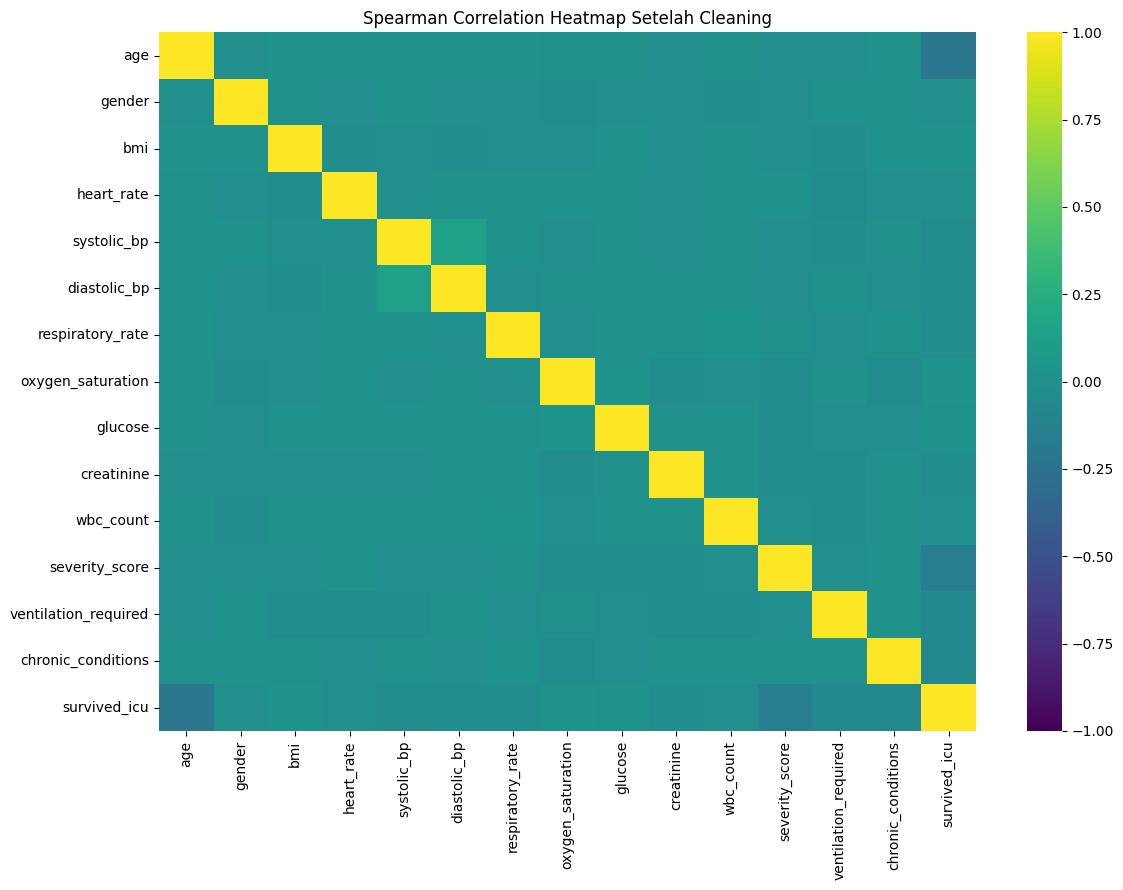

In [37]:
numeric_cols = df_clean.select_dtypes(include="number").columns
corr_spearman = df_clean[numeric_cols].corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_spearman,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    annot=False
)
plt.title("Spearman Correlation Heatmap Setelah Cleaning")
plt.tight_layout()
plt.show()

In [38]:
corr_target = (
    corr_spearman["survived_icu"]
    .drop("survived_icu")
    .sort_values(key=abs, ascending=False)
)

display(
    corr_target.to_frame("Spearman_Correlation").round(3)
)

,Spearman_Correlation
age,-0.206
severity_score,-0.153
ventilation_required,-0.062
chronic_conditions,-0.057
systolic_bp,-0.038
oxygen_saturation,0.031
diastolic_bp,-0.031
bmi,0.028
creatinine,-0.028
respiratory_rate,-0.018


## 5. Supervised Learning

**Supervised learning** adalah pembelajaran mesin menggunakan data yang sudah mempunyai **label/target**.

Pada kasus ini:

- **Input (X):** karakteristik pasien ICU.
- **Target (y):** **survived_icu**.
- Model belajar hubungan X → y dari data training.
- Setelah belajar, model diuji pada data testing yang tidak digunakan saat training.

Karena target hanya memiliki dua kelas (0 dan 1), kita menggunakan **klasifikasi biner**.

### 5.1 Menentukan X dan y + Train-Test Split

Data dibagi menjadi training dan testing sebelum preprocessing yang mempelajari parameter dari data. Ini dilakukan untuk menghindari **data leakage**.

In [39]:
X = df_clean.drop(columns=["patient_id", "survived_icu"])
y = df_clean["survived_icu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

print("\nDistribusi target training:")
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribusi target testing:")
display(y_test.value_counts(normalize=True).mul(100).round(2))

Data training: (3544, 14)
Data testing : (886, 14)

Distribusi target training:


survived_icu
1    64.53
0    35.47
Name: proportion, dtype: float64


Distribusi target testing:


survived_icu
1    64.56
0    35.44
Name: proportion, dtype: float64

### 5.2 Preprocessing untuk Logistic Regression

Langkah preprocessing yang dipakai sengaja sederhana:

1. **Median imputation** → mengisi missing value numerik dengan nilai tengah.
2. **StandardScaler** → menyamakan skala fitur agar fitur dengan rentang besar tidak mendominasi proses optimasi.
3. **Logistic Regression** → model klasifikasi biner.

Semua langkah dimasukkan ke dalam **Pipeline** supaya preprocessing training dan testing konsisten serta mengurangi risiko data leakage.

In [40]:
numeric_features = X_train.columns.tolist()

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

model.fit(X_train, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


### 5.3 Prediksi

In [41]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("10 hasil prediksi pertama:")
display(pd.DataFrame({
    "Aktual": y_test.iloc[:10].values,
    "Prediksi": y_pred[:10],
    "Probabilitas_survive": np.round(y_proba[:10], 3)
}))

10 hasil prediksi pertama:


,Aktual,Prediksi,Probabilitas_survive
0,0,1,0.750
1,1,1,0.731
2,0,1,0.582
3,1,1,0.755
4,1,1,0.632
5,1,1,0.876
6,1,1,0.675
7,0,0,0.444
8,1,1,0.754
9,0,1,0.518


## 6. Evaluasi Model

Beberapa metrik digunakan agar performa tidak hanya dilihat dari accuracy:

- **Accuracy:** proporsi prediksi yang benar dari seluruh data.
- **Precision:** dari semua yang diprediksi selamat, berapa yang benar-benar selamat.
- **Recall:** dari semua pasien yang benar-benar selamat, berapa yang berhasil dikenali model.
- **F1-score:** keseimbangan antara precision dan recall.
- **ROC-AUC:** kemampuan model membedakan dua kelas berdasarkan probabilitas prediksi.

Untuk tugas klasifikasi biner, melihat beberapa metrik lebih informatif daripada hanya accuracy.

In [42]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

results = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Nilai": [accuracy, precision, recall, f1, roc_auc]
})

display(results.round(4))

,Metrik,Nilai
0,Accuracy,0.6637
1,Precision,0.6822
2,Recall,0.8969
3,F1-Score,0.7749
4,ROC-AUC,0.6562


### 6.1 Classification Report

In [43]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Tidak Selamat (0)", "Selamat (1)"],
    zero_division=0
))

                   precision    recall  f1-score   support

Tidak Selamat (0)       0.56      0.24      0.33       314
      Selamat (1)       0.68      0.90      0.77       572

         accuracy                           0.66       886
        macro avg       0.62      0.57      0.55       886
     weighted avg       0.64      0.66      0.62       886



### 6.2 Confusion Matrix

Confusion matrix menunjukkan jumlah prediksi yang benar dan salah untuk masing-masing kelas.

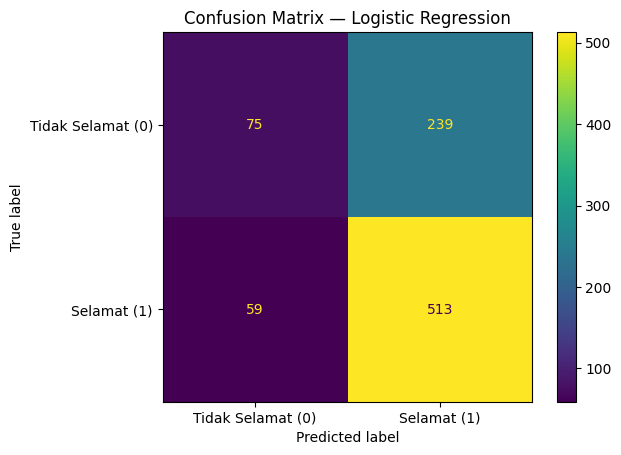

In [44]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Selamat (0)", "Selamat (1)"]
)

disp.plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

### 6.3 ROC Curve

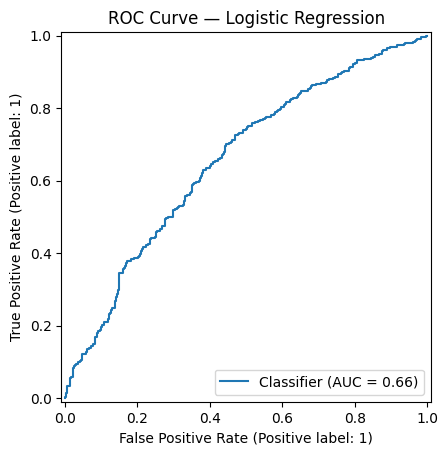

In [45]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Logistic Regression")
plt.show()

## 7. Interpretasi Koefisien Logistic Regression

Logistic Regression menghasilkan **koefisien** untuk setiap fitur.

- Koefisien **positif** → kenaikan fitur cenderung meningkatkan peluang kelas 1 (**survived_icu = 1**).
- Koefisien **negatif** → kenaikan fitur cenderung menurunkan peluang kelas 1.
- Semakin besar nilai absolut koefisien, semakin kuat pengaruh linear fitur terhadap log-odds target, dengan asumsi fitur lain tetap.

Karena fitur sudah di-**StandardScaler**, besar koefisien dapat dibandingkan dengan lebih masuk akal antarfitur.

In [46]:
lr = model.named_steps["logistic_regression"]

coef = pd.Series(
    lr.coef_[0],
    index=numeric_features
).sort_values()

coef_table = pd.DataFrame({
    "Fitur": coef.index,
    "Koefisien": coef.values,
    "Arah": np.where(coef.values > 0, "Positif", "Negatif")
})

display(coef_table.round(4))

,Fitur,Koefisien,Arah
0,age,-0.4986,Negatif
1,severity_score,-0.3519,Negatif
2,chronic_conditions,-0.1320,Negatif
3,ventilation_required,-0.1269,Negatif
4,creatinine,-0.0906,Negatif
5,systolic_bp,-0.0797,Negatif
6,heart_rate,-0.0522,Negatif
7,respiratory_rate,-0.0516,Negatif
8,diastolic_bp,-0.0435,Negatif
9,gender,-0.0143,Negatif


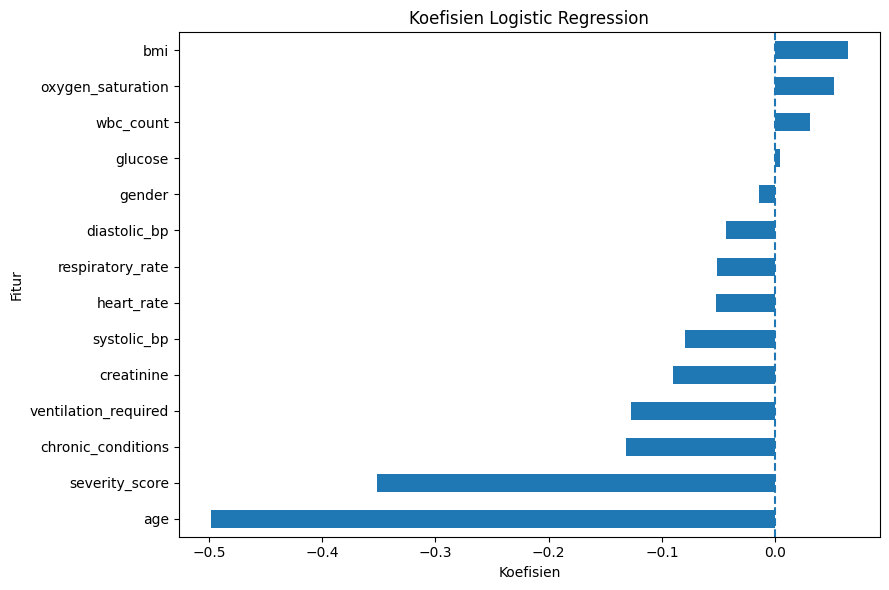

In [47]:
plt.figure(figsize=(9, 6))
coef.sort_values().plot(kind="barh")
plt.axvline(0, linestyle="--")
plt.title("Koefisien Logistic Regression")
plt.xlabel("Koefisien")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

### 7.1 Interpretasi Praktis

Interpretasi berikut dibaca dari tanda dan besar koefisien, bukan sebagai hubungan sebab-akibat. Model hanya menemukan pola prediktif pada data.

- Fitur dengan koefisien positif cenderung berkaitan dengan probabilitas **survived_icu = 1** yang lebih tinggi.
- Fitur dengan koefisien negatif cenderung berkaitan dengan probabilitas **survived_icu = 1** yang lebih rendah.
- Fitur dengan koefisien mendekati nol memberikan kontribusi linear yang relatif kecil dalam model.
- **Koefisien bukan bukti bahwa suatu fitur menyebabkan pasien selamat atau tidak selamat.** Ini adalah hubungan prediktif dalam model.

Untuk laporan, gunakan nilai koefisien yang muncul dari output notebook setelah dijalankan sebagai dasar menyebut fitur paling positif dan paling negatif.

In [48]:
top_positive = coef.sort_values(ascending=False).head(5)
top_negative = coef.sort_values().head(5)

print("5 fitur dengan koefisien paling positif:")
display(top_positive.to_frame("Koefisien").round(4))

print("\n5 fitur dengan koefisien paling negatif:")
display(top_negative.to_frame("Koefisien").round(4))

5 fitur dengan koefisien paling positif:


,Koefisien
bmi,0.0644
oxygen_saturation,0.0516
wbc_count,0.0305
glucose,0.0045
gender,-0.0143



5 fitur dengan koefisien paling negatif:


,Koefisien
age,-0.4986
severity_score,-0.3519
chronic_conditions,-0.1320
ventilation_required,-0.1269
creatinine,-0.0906


## 8. Perbandingan Logistic Regression Tanpa dan Dengan StandardScaler

Sebagai pembanding sederhana, model baseline hanya melakukan **median imputation**, sedangkan model akhir melakukan **median imputation + StandardScaler**.

Perbandingan ini membantu menunjukkan apakah preprocessing yang digunakan memberikan perubahan performa.

In [49]:
baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("logistic_regression", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression + Scaling"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, y_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall
    ],
    "F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_proba),
        roc_auc
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.6625,0.6818,0.8951,0.7740,0.6562
1,Logistic Regression + Scaling,0.6637,0.6822,0.8969,0.7749,0.6562


## 9. Kesimpulan

### Temuan Data
Dataset ICU memiliki beberapa masalah kualitas data, terutama **missing value, duplicate, nilai ekstrem/corrupted, outlier, dan inkonsistensi tekanan darah**. Masalah tersebut diperiksa terlebih dahulu sebelum modeling.

### Preprocessing
Cleaning dilakukan dengan membuang duplicate dan corrupted extreme rows serta memperbaiki ketidakkonsistenan tekanan darah. Missing value tidak dibuang seluruhnya karena dapat mengurangi jumlah data; sebagai gantinya, model menggunakan **median imputation**.

### Visualisasi
- **Histogram** digunakan untuk melihat distribusi masing-masing fitur.
- **Boxplot** digunakan untuk mendeteksi kandidat outlier.
- **Heatmap** digunakan untuk melihat korelasi antarvariabel.

### Supervised Learning
Karena target **survived_icu** adalah biner, masalah ini merupakan **binary classification**. Model yang digunakan adalah **Logistic Regression**.

### Interpretasi Model
Koefisien Logistic Regression menunjukkan arah hubungan prediktif setiap fitur terhadap peluang **survived_icu = 1**. Koefisien positif menunjukkan arah positif, sedangkan koefisien negatif menunjukkan arah negatif. Interpretasi harus dibaca sebagai **hubungan prediktif**, bukan hubungan sebab-akibat.

### Evaluasi
Performa model dinilai menggunakan **Accuracy, Precision, Recall, F1-Score, ROC-AUC, confusion matrix, dan ROC curve**. Nilai aktual mengikuti output saat notebook dijalankan.

## 10. Ringkasan Alur

```text
Dataset ICU
    ↓
Data Understanding
    ↓
Cek kolom + missing + duplicate + outlier + consistency
    ↓
Data Cleaning
    ↓
Histogram + Boxplot + Heatmap
    ↓
Pisahkan X dan y
    ↓
Train-Test Split
    ↓
Median Imputation
    ↓
Standard Scaling
    ↓
Logistic Regression
    ↓
Prediksi
    ↓
Evaluasi
    ↓
Interpretasi koefisien
```

**Inti tugas:** data yang kotor dibersihkan dan dipersiapkan terlebih dahulu, kemudian digunakan untuk supervised learning dengan Logistic Regression.